<a href="https://colab.research.google.com/github/ArpitaRPatki/NLP-LAB/blob/main/NLP_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Cell 1: Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

print("Libraries imported!")
print("TensorFlow version:", tf.__version__)

Libraries imported!
TensorFlow version: 2.19.0


In [12]:
# Cell 2: Simple text corpus
text = """
the cat sat on the mat and the cat is fat
the dog ran in the park near the lake
the sun is bright and the sky is blue
birds sing songs in the morning light
children love to play in the park
the moon glows bright in the night sky
flowers bloom in spring and summer days
the river flows fast through the valley
""".lower().strip()

# Get all unique characters
chars    = sorted(set(text))
vocab_size = len(chars)

# Create mappings
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}

# Encode full text
encoded = [char2idx[c] for c in text]

print("Text ready!")
print("Vocabulary size :", vocab_size)
print("Unique chars    :", ''.join(chars))
print("Total characters:", len(text))

Text ready!
Vocabulary size : 24
Unique chars    : 
 abcdefghiklmnoprstuvwy
Total characters: 308


In [13]:
# Cell 3: Create input/output sequences
seq_length = 15
X_data, y_data = [], []

for i in range(len(encoded) - seq_length):
    X_data.append(encoded[i : i + seq_length])
    y_data.append(encoded[i + seq_length])

X = np.array(X_data)
y = to_categorical(y_data, num_classes=vocab_size)

print("Sequences created!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sample input  :", ''.join([idx2char[i] for i in X[0]]))
print("Target char   :", idx2char[np.argmax(y[0])])

Sequences created!
X shape: (293, 15)
y shape: (293, 24)
Sample input  : the cat sat on 
Target char   : t


In [14]:
# Cell 4: Build the RNN model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=seq_length),
    SimpleRNN(128, activation='tanh'),
    Dense(64, activation='relu'),
    Dense(vocab_size, activation='softmax')
])

model.build(input_shape=(None, seq_length))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()
print("\nModel built successfully!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 15, 32)         │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,192 (121.84 KB)

 Trainable params: 31,192 (121.84 KB)

 Non-trainable params: 0 (0.00 B)


Model built successfully!


In [15]:
# Cell 5: Train the model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='accuracy', patience=8,
                           restore_best_weights=True, verbose=1)

print("Training started...\n")

history = model.fit(
    X, y,
    epochs=120,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

acc = history.history['accuracy'][-1] * 100
print(f"\nTraining complete! Final Accuracy: {acc:.2f}%")

Training started...

Epoch 1/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0922 - loss: 3.1433
Epoch 2/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1809 - loss: 2.9669 
Epoch 3/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1809 - loss: 2.9072 
Epoch 4/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1809 - loss: 2.8389 
Epoch 5/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1809 - loss: 2.7661 
Epoch 6/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2287 - loss: 2.6499 
Epoch 7/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2594 - loss: 2.5396 
Epoch 8/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3106 - loss: 2.4040 
Epoch 9/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3584 - loss: 2.2937 
Epoch 10/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3754 - loss: 2.1654
Epoch 11/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3993 - loss: 2.0561 
Epoch 12/120
10/10 ━━━━━━━━━━━━━

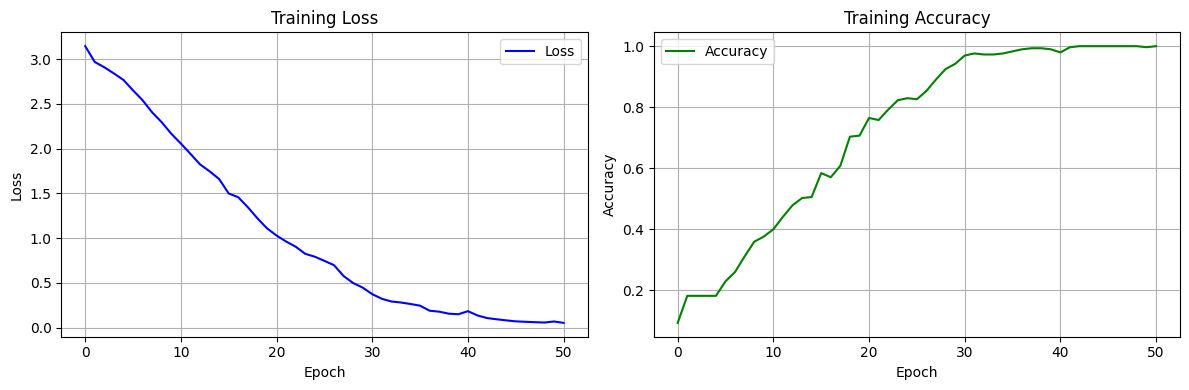

Plots shown!


In [16]:
# Cell 6: Plot training graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], color='blue', label='Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], color='green', label='Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
print("Plots shown!")

In [17]:
# Cell 7: Function to generate text from seed
def generate_text(seed, num_chars=60):
    result = seed
    seq    = seed.lower()

    for _ in range(num_chars):
        # Encode seed
        enc = [char2idx.get(c, 0) for c in seq[-seq_length:]]

        # Pad if needed
        if len(enc) < seq_length:
            enc = [0] * (seq_length - len(enc)) + enc

        X_in = np.array([enc])
        pred = model.predict(X_in, verbose=0)[0]

        # Pick most likely next character
        next_idx  = np.argmax(pred)
        next_char = idx2char[next_idx]

        result += next_char
        seq    += next_char

    return result

print("Text generation function ready!")

Text generation function ready!


In [18]:
# Cell 8: Generate text from 15 different seeds — SCREENSHOT THIS!

seeds = [
    "the cat sat",
    "the dog ran",
    "the sun is",
    "birds sing",
    "children love",
    "the moon glo",
    "flowers bloo",
    "the river fl",
    "the sky is b",
    "the mat and",
    "morning ligh",
    "spring and s",
    "the park nea",
    "the night sk",
    "the valley a"
]

print("=" * 68)
print("      RNN LANGUAGE MODEL — 15 TEXT GENERATION OUTPUTS")
print("=" * 68)

for i, seed in enumerate(seeds, 1):
    output = generate_text(seed, num_chars=45)
    print(f"\n {i:2}. Seed     : \"{seed}\"")
    print(f"     Generated : \"{output}\"")

print("\n" + "=" * 68)
print(f"  Model Final Accuracy : {history.history['accuracy'][-1]*100:.2f}%")
print(f"  Total Parameters     : {model.count_params():,}")
print(f"  Vocabulary Size      : {vocab_size} characters")
print(f"  Sequence Length      : {seq_length}")
print("=" * 68)

      RNN LANGUAGE MODEL — 15 TEXT GENERATION OUTPUTS

  1. Seed     : "the cat sat"
     Generated : "the cat sat n  the mat ras isgthe mat in  rathe cidgs ma"

  2. Seed     : "the dog ran"
     Generated : "the dog ran y  the park bia  the lake ss tre fan ss toe
"

  3. Seed     : "the sun is"
     Generated : "the sun is n  ght and she mgt is btsrot rid the sor il "

  4. Seed     : "birds sing"
     Generated : "birds sing n ngs in thr mo  ing lill ran gsrinsan iki m"

  5. Seed     : "children love"
     Generated : "children love to play in the park
the moon glows bright in"

  6. Seed     : "the moon glo"
     Generated : "the moon glows bright in the night sky
flowers bloom in s"

  7. Seed     : "flowers bloo"
     Generated : "flowers bloo  in spring ann summer days
the river flows f"

  8. Seed     : "the river fl"
     Generated : "the river fl ss fast th in tha  iy the rathe  ay 
the san"

  9. Seed     : "the sky is b"
     Generated : "the sky is b tg
birds sing hangs i